![lop](../../../images/logo_diive1_128px.png)

<span style='font-size:24px; display:block;'>Self-heating correction for open-path IRGA fluxes (NEE)</span>
<span style='font-size:40px; display:block;'><b>Apply scaling factors table</b></span> 

---
**Notebook version**: `1` (13 Jan 2026)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

# General info

- This example applies the self-heating correction to long-term open-path fluxes (NEE, 2004-2019)
- The class `ScopApplicator` uses info from the **scaling factors table** to correct open-path NEE fluxes
- The table contains info about the scaling factor, i.e., how much of the self-heating correction needs to be applied to the open-path fluxes during different conditions
- Scaling factors were determined in 20 classes of USTAR, separately for daytime and nighttime data
- The table was calculated in a previous step, see notebook [SelfHeatingCorrectionNEE_1_CreateScalingFactorsTable](SelfHeatingCorrectionNEE_1_CreateScalingFactorsTable.ipynb)
- In essence, the **scaling factors table** is used as look-up table to correct open-path fluxes
- Required steps: 
    - Step 1: Calculate unscaled flux correction term with `ScopPhysics`    
    - Step 2: Correct open-path fluxes with `ScopApplicator` (applies scaling factors table)
    - Note that running `ScopOptimizer` is not needed here, because the scaling factors were already optimized before, the scaling factors table is already available

</br>

# Imports

In [1]:
from datetime import datetime
from pathlib import Path
import pandas as pd
from diive.core.io.files import save_parquet, load_parquet
from diive.pkgs.flux.selfheating import ScopPhysics, ScopOptimizer, ScopApplicator

# Docstring

In [2]:
help(ScopApplicator)

Help on class ScopApplicator in module diive.pkgs.flux.selfheating:

class ScopApplicator(builtins.object)
 |  ScopApplicator(flux_type: Literal['CO2', 'H2O'], fct_unsc: pandas.core.series.Series, scaling_factors_df: pandas.core.frame.DataFrame, flux_openpath: pandas.core.series.Series, classvar: pandas.core.series.Series, daytime: pandas.core.series.Series, latent_heat_vaporization: Optional[pandas.core.series.Series] = None)
 |  
 |  Methods defined here:
 |  
 |  __init__(self, flux_type: Literal['CO2', 'H2O'], fct_unsc: pandas.core.series.Series, scaling_factors_df: pandas.core.frame.DataFrame, flux_openpath: pandas.core.series.Series, classvar: pandas.core.series.Series, daytime: pandas.core.series.Series, latent_heat_vaporization: Optional[pandas.core.series.Series] = None)
 |      Args:
 |          flux_type: "CO2" or "H2O"
 |          latent_heat_vaporization: Series of Lambda (J/mmol or J/kg depending on inputs).
 |                                    Required ONLY if flux_type

# Load data

In [3]:
SOURCEDIR = r"../../20_MERGE_DATA"
FILENAME = r"21.4_FLUXES_L1_noSHC_IRGA75+METEO7.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
print(f"Data will be loaded from the following file:\n{FILEPATH}")
df = load_parquet(filepath=FILEPATH)
df

Data will be loaded from the following file:
..\..\20_MERGE_DATA\21.4_FLUXES_L1_noSHC_IRGA75+METEO7.parquet
Loaded .parquet file ..\..\20_MERGE_DATA\21.4_FLUXES_L1_noSHC_IRGA75+METEO7.parquet (0.413 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,...,W_T_SONIC_COV_IBROM_N1626,W_UNROT,W_U_COV,W_VM97_TEST,W_ZCD,ZL,ZL_UNCORR
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,
2004-03-30 14:45:00,1005.41,1.12844,0.025668,1134.55,0.0,1.0,37.0,...,0.429576,-0.227060,-0.209191,800000001.0,14.0,-1.260300,-1.311810
2004-03-30 15:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-03-30 15:45:00,1005.42,1.12663,0.025709,1132.74,0.0,1.0,37.0,...,0.208402,-0.063026,0.002830,800000001.0,39.0,-0.350351,-0.361224
2004-03-30 16:15:00,1005.43,1.12587,0.025726,1131.98,0.0,1.0,37.0,...,0.130654,-0.028456,-0.034904,800000000.0,76.0,-0.295734,-0.304238
2004-03-30 16:45:00,1005.44,1.12521,0.025742,1131.33,0.0,1.0,37.0,...,0.090910,0.371090,-0.012976,800000000.0,247.0,-0.702368,-0.729167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Calculate unscaled flux correction term with `ScopPhysics`

In [4]:
physics = ScopPhysics(
    flux_type="CO2",
    ta=df["TA_T1_47_1"].copy(),
    gas_density=df["CO2_MOLAR_DENSITY"].copy() * 1000,  # Requires umol m-3
    rho_a=df["AIR_DENSITY"].copy(),
    rho_v=df["VAPOR_DENSITY"].copy(),
    u=df["U"].copy(),
    c_p=df["AIR_CP"].copy(),
    ustar=df["USTAR"].copy(),    
    lat=47.478333,  # CH–LAE
    lon=8.364389,  # CH–LAE
    utc_offset=1,
)
physics.run(correction_method_base="JAR09", gapfill=True)
results_physics_df = physics.get_results()

Aerodynamic resistance: Mean = 25.97 s m-1
Dry air density: Mean = 1.1440 kg m-3


Starting gap-filling for
FCT_UNSC
using <class 'sklearn.ensemble._forest.RandomForestRegressor'>

Adding new data columns ...
++ Added new columns with lagged variants for: ['TA_T1_47_1', 'AIR_CP', 'AIR_DENSITY', 'U', 'USTAR'] (lags between -1 and -1 with stepsize 1), no lagged variants for: ['FCT_UNSC']. Shifting the time series created gaps which were then filled with the nearest value.
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 185367.

Sanitizing timestamp ...
>>> Validating timestamp naming of timestamp column TIMESTAMP_MIDDLE ... Timestamp name OK.
>>> Converting timestamp TIMESTAMP_MIDDLE to datetime ... OK
>

In [5]:
results_physics_df.describe()

,FCT_UNSC_gfRF,FCT_UNSC,TS,TA_T1_47_1,AIR_CP,AERODYNAMIC_RESISTANCE,AIR_DENSITY,...,U,USTAR,CO2_MOLAR_DENSITY,SW_IN_POT,AIR_THERMAL_CONDUCTIVITY,DAYTIME,LATENT_HEAT_VAPORIZATION_J_UMOL
count,276211.000000,185367.000000,265180.000000,265180.000000,237184.000000,215087.000000,237184.000000,...,237184.000000,237184.000000,219670.000000,276211.000000,265180.000000,276211.000000,265180.000000
mean,15.300387,15.857694,10.562362,8.420737,1010.532462,13.104677,1.150846,...,2.487897,0.488472,15897.744208,297.445011,0.024839,0.492620,0.044697
std,11.266251,12.724288,8.183958,8.197828,2.567790,11.109658,0.034960,...,1.802394,0.305275,2342.644800,385.270382,0.000574,0.499946,0.000350
min,0.872043,0.872043,-16.540001,-17.200001,971.364000,0.031634,1.053700,...,0.009557,0.007408,7997.360000,0.000000,0.023046,0.000000,0.043628
25%,7.848754,6.517549,4.233200,2.050000,1008.550000,5.548491,1.124640,...,1.159165,0.252583,14670.000000,0.000000,0.024393,0.000000,0.044440
50%,12.156313,12.291183,10.707500,8.443055,1010.150000,9.284189,1.148710,...,2.051880,0.432681,15479.900000,3.105271,0.024841,0.000000,0.044696
75%,19.584172,21.322798,16.636400,14.440464,1012.310000,16.787022,1.176350,...,3.358270,0.658532,16398.975000,556.621671,0.025261,1.000000,0.044969
max,105.960488,105.960488,34.840751,33.445910,1021.520000,85.902511,1.278340,...,13.249100,3.322560,37033.300000,1241.991455,0.026591,1.000000,0.045791


In [6]:
physics.stats()


SCOP PHYSICS DIAGNOSTICS (CO2)
1. DATA COVERAGE & GAP-FILLING
------------------------------
   Total Timestamps       : 276,211
   Raw Physics Calculated : 185,367  ( 67.1%)
   Final Gap-Filled (GF)  : 276,211  (100.0%)
   -> Imputed (RF + MDV)  : 90,844  ( 32.9%)

2. INSTRUMENT SELF-HEATING (Ts - Ta)
------------------------------
   Avg Daytime Heating    : +2.45 °C
   Max Daytime Heating    : +4.36 °C
   Avg Nighttime Offset   : +1.85 °C

3. UNSCALED CORRECTION TERM (FCT_unsc)
   (Units: µmol m-2 s-1)
------------------------------
   DAYTIME   : +19.4470 ± 12.3711  [Range: 0.87 to 105.96]
   NIGHTTIME : +11.2744 ± 8.2868  [Range: 1.08 to 100.99]

4. KEY DRIVERS (Daytime Avg)
------------------------------
   Radiation (SW_IN)      : 604 W m-2
   Wind Speed (U)         : 2.33 m s-1
   Aero Resistance (Ra)   : 10.7 s m-1



Plotting Physics Diel Cycles...


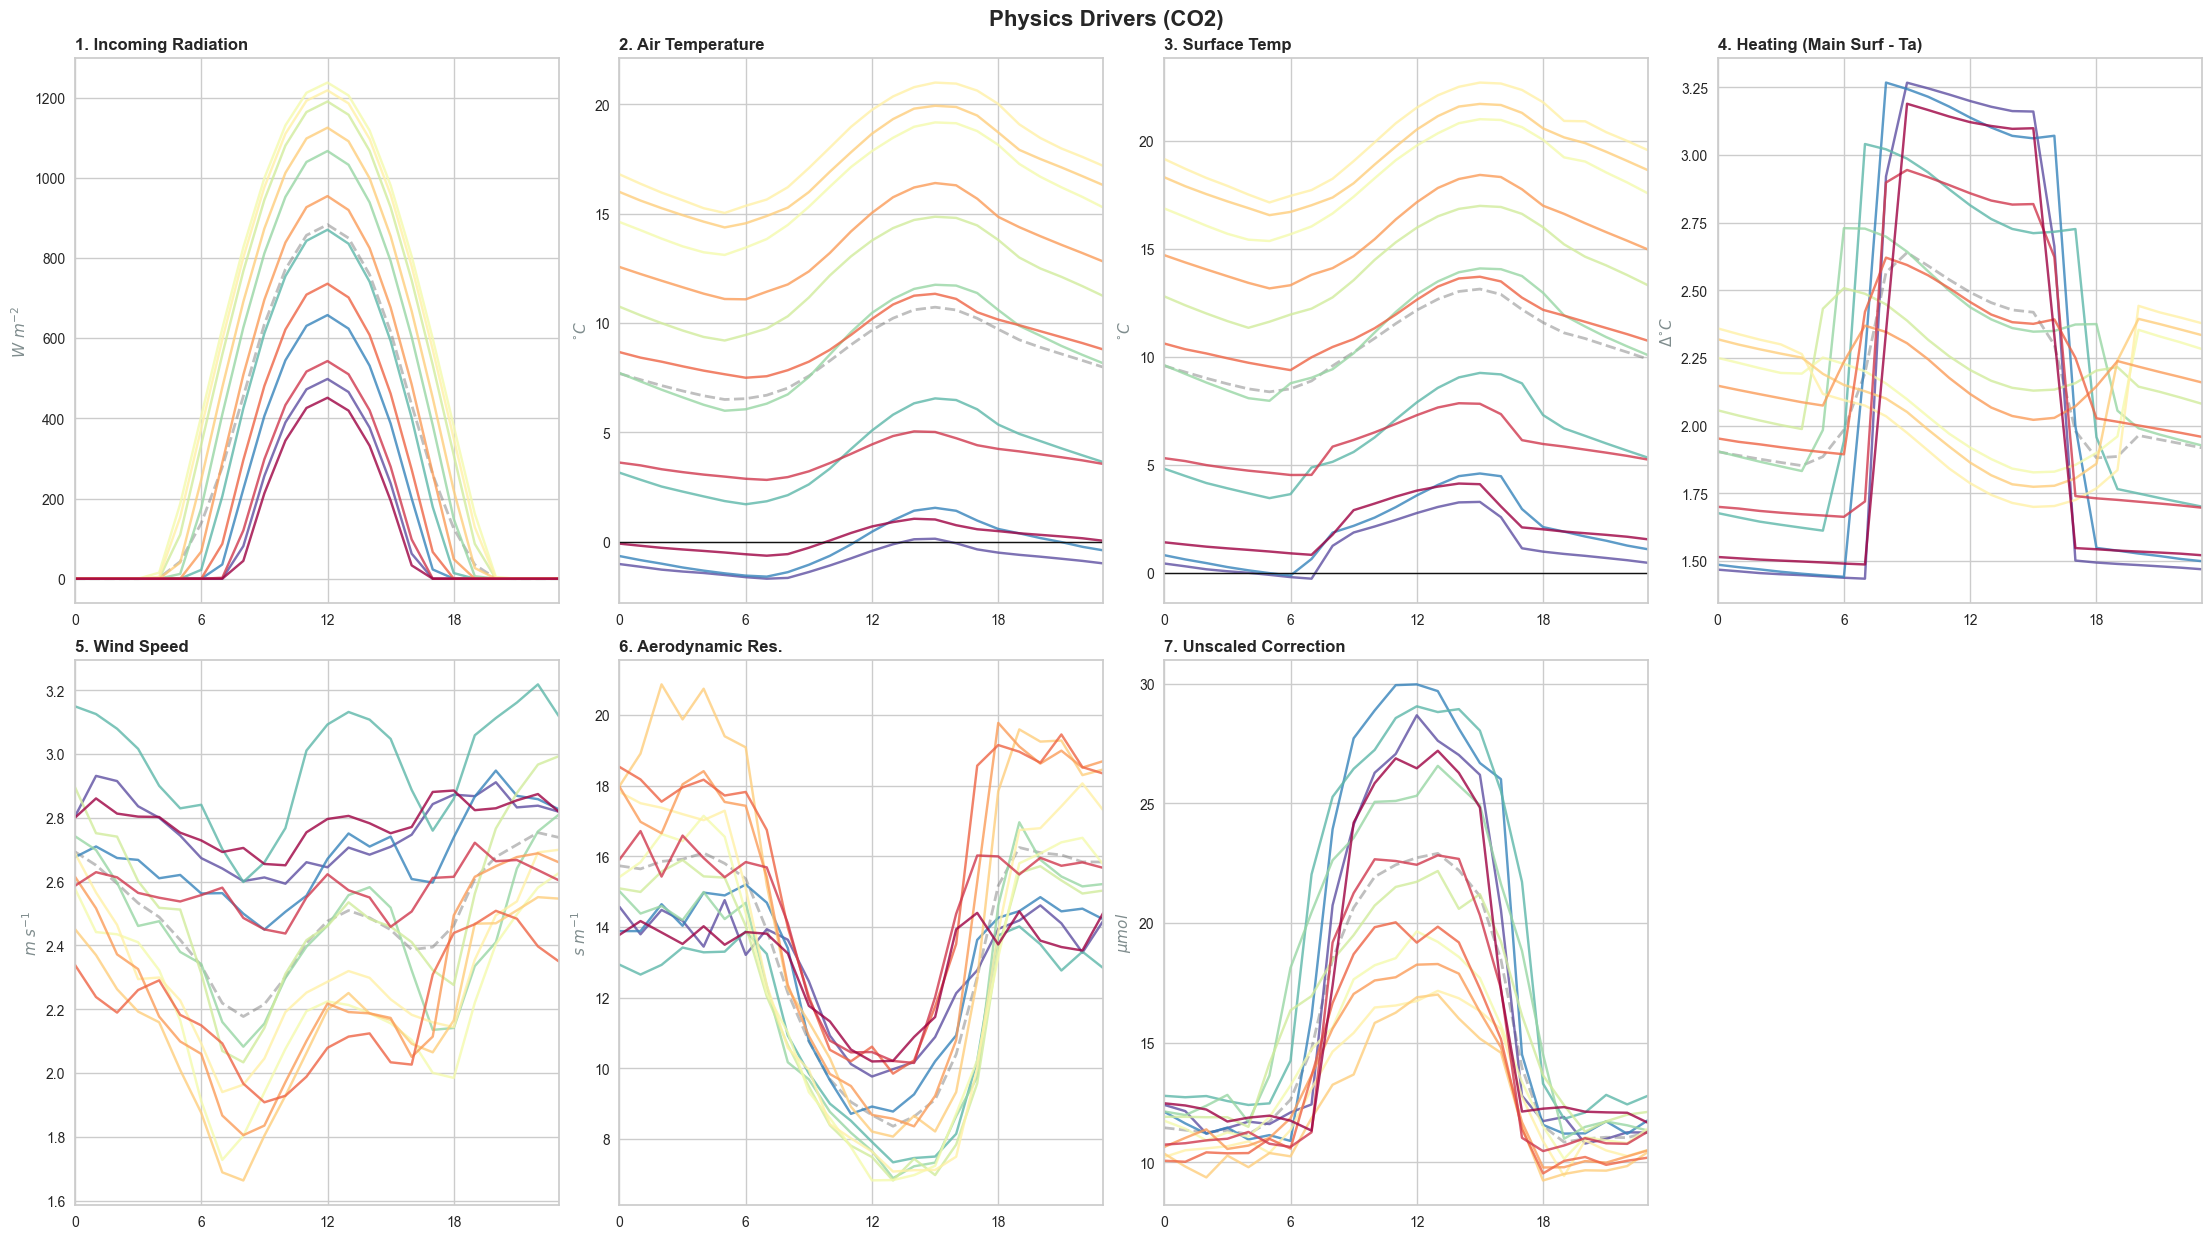

In [7]:
physics.plot_diel_cycles()

# Load scaling factors from `ScopOptimizer`

In [8]:
sfdf = pd.read_csv("32_SelfHeatingCorrection_ScalingFactors_NEE-QCF11.csv")
sfdf

,Unnamed: 0,DAYTIME,GROUP_CLASSVAR,GROUP_CLASSVAR_MIN,GROUP_CLASSVAR_MAX,BOOTSTRAP_RUNS,SF_MEDIAN,SF_Q25,SF_Q75,SF_Q01,SF_Q99,SOS_MEDIAN,NUMVALS_AVG
0,0,0.0,0.0,0.009705,0.092042,100,0.016973,0.012761,0.022988,0.003822,0.048083,587.830362,231
1,1,0.0,1.0,0.092100,0.118560,100,0.029399,0.021075,0.035533,0.013061,0.055320,728.977155,225
2,2,0.0,2.0,0.119289,0.143188,100,0.049233,0.039112,0.068600,0.018364,0.123256,1287.671825,239
3,3,0.0,3.0,0.143325,0.165168,100,0.060092,0.052410,0.067029,0.038686,0.085068,839.822373,230
4,4,0.0,4.0,0.165365,0.188061,100,0.063731,0.049846,0.075183,0.023922,0.104031,1340.235527,231
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,35,1.0,15.0,0.673752,0.726408,100,0.132327,0.126120,0.137104,0.115221,0.151358,7859.420807,453
36,36,1.0,16.0,0.726704,0.792686,100,0.130262,0.124359,0.137891,0.103369,0.161459,8238.457540,419
37,37,1.0,17.0,0.793117,0.880232,100,0.112175,0.106470,0.116309,0.094342,0.127351,6577.682106,421
38,38,1.0,18.0,0.880409,1.023690,100,0.112530,0.106976,0.122097,0.088693,0.141928,9456.339846,396


# Correct open-path fluxes with `ScopApplicator`

In [9]:
applicator = ScopApplicator(
    flux_type="CO2",
    fct_unsc=results_physics_df["FCT_UNSC_gfRF"],
    scaling_factors_df=sfdf,
    flux_openpath=df["FC"].copy(),
    classvar=df["USTAR"].copy(),
    daytime=results_physics_df["DAYTIME"].copy()
)
applicator.run()

(!) Warning: 39027 fluxes missing Scaling Factor (due to missing USTAR).
    Imputing using Month-Daytime-Hour-Minute Diel Cycle Median...
    > Successfully imputed 39027 missing Scaling Factors.


In [10]:
res = applicator.get_results()

In [11]:
res.describe()

,FCT_UNSC_gfRF,FC,USTAR,DAYTIME,GROUP_CLASSVAR,SF,FCT,NEE_OP_CORR
count,276211.000000,219562.000000,237184.000000,276211.000000,237184.000000,276211.000000,276211.000000,219562.000000
mean,15.300387,-3.388636,0.488472,0.492620,10.021338,0.133984,2.056760,-1.355543
std,11.266251,91.136919,0.305275,0.499946,5.839639,0.090824,2.010692,91.134127
min,0.872043,-5050.860000,0.007408,0.000000,0.000000,0.016973,0.020209,-5049.226415
25%,7.848754,-8.323713,0.252583,0.000000,5.000000,0.063731,0.607059,-5.766817
50%,12.156313,-0.750189,0.432681,0.000000,10.000000,0.091672,1.383549,0.395998
75%,19.584172,2.596885,0.658532,1.000000,15.000000,0.188741,2.944460,4.401615
max,105.960488,3725.790000,3.322560,1.000000,19.000000,0.375206,31.611307,3726.171700


In [12]:
applicator.stats()



                          FLUX CORRECTION REPORT                           
Flux Type      : CO2
Total Records  : 219,562
---------------------------------------------------------------------------
1. SCALING FACTOR ASSIGNMENT                                  (Method Used)
...........................................................................
   Direct Lookup (Valid USTAR) :  219,562  (100.0%)
 i Gap-Filled    (MDV Imputation) :        0  (  0.0%)

   Median Scaling Factor (Day)     : 0.189
   Median Scaling Factor (Night)   : 0.064


2. CORRECTION IMPACT (Budget)                                  (Units: Sum)
...........................................................................
   Uncorrected Sum                 :        -744,016
   Corrected Sum                   :        -297,626
   Net Adjustment                  :         446,390  (+60.0%)




Generating Comprehensive Flux Dashboard (Large Font Edition)...


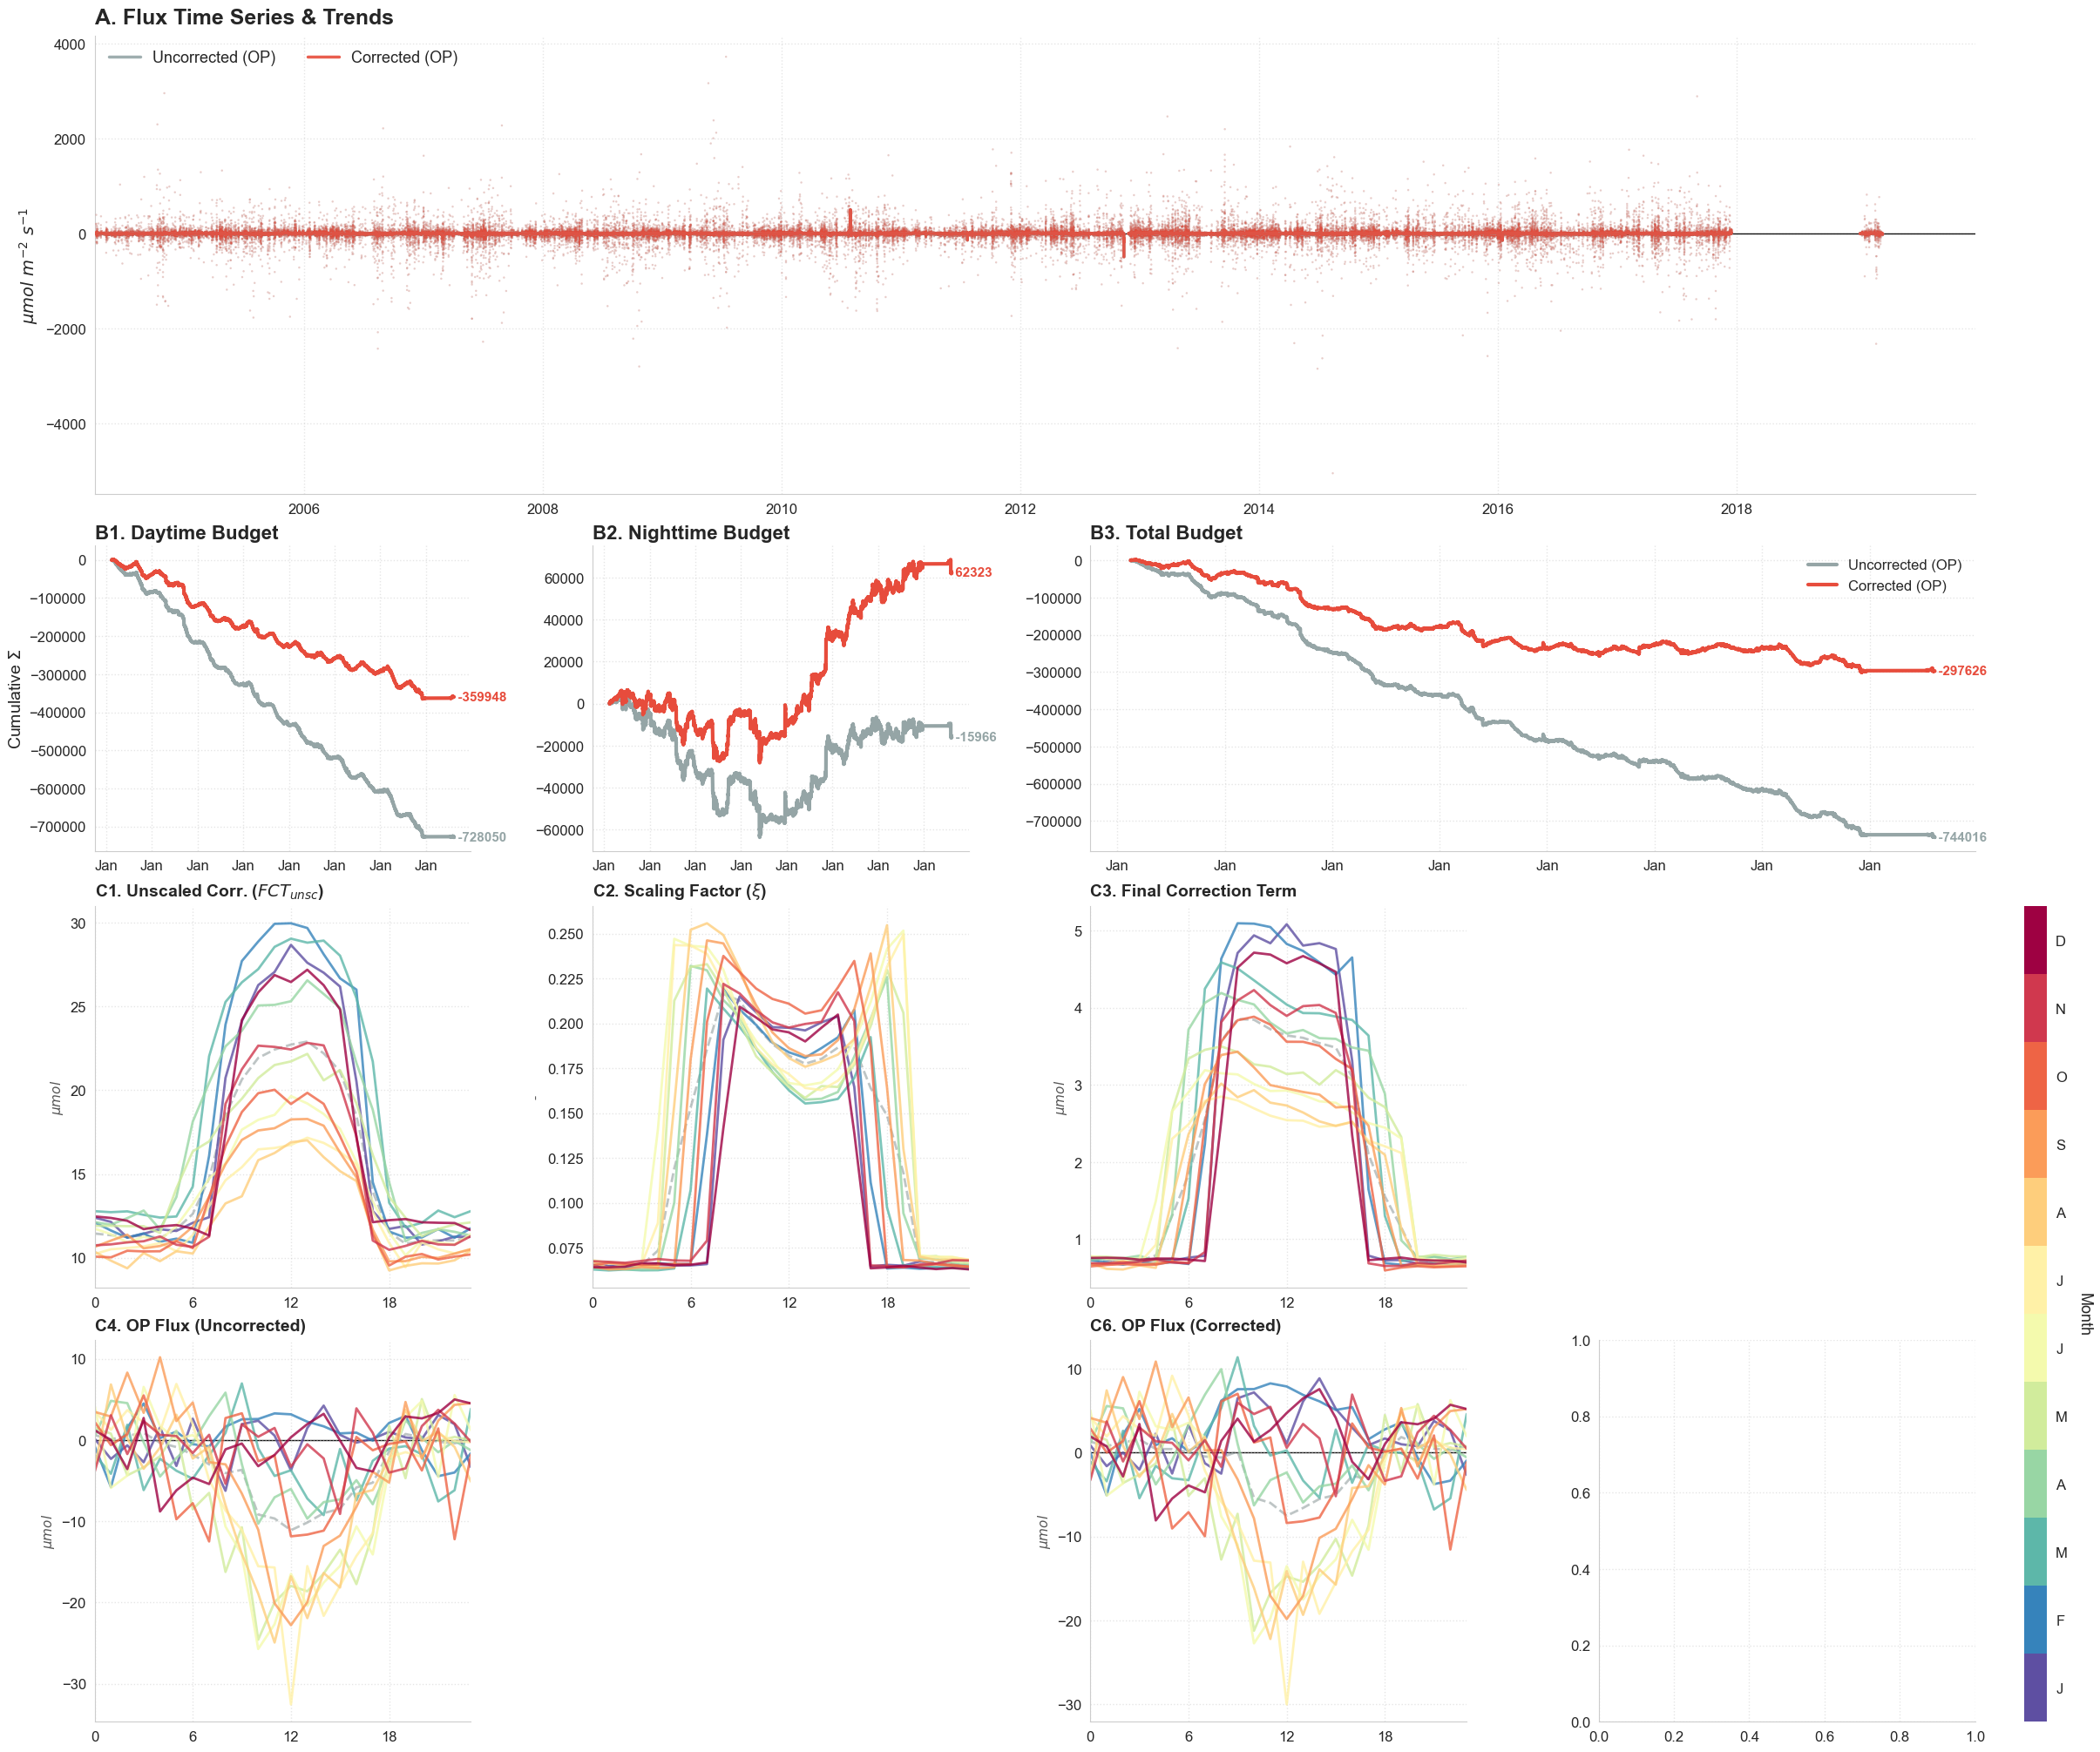

In [13]:
applicator.plot_dashboard();

# Compare results to IRGA72 during the time period with parallel measurements
- Comparison is not perfect, because correction was derived using quality-checked and outlier-removed FC (labelled as NEE) data
- Nevertheless it gives an idea of how the correction affects the data

Loaded .parquet file ../../20_MERGE_DATA/22.4_FLUXES_L1_IRGA72+METEO7_2016-2024.parquet (0.203 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Loaded .parquet file ../../20_MERGE_DATA/21.4_FLUXES_L1_noSHC_IRGA75+METEO7.parquet (0.373 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


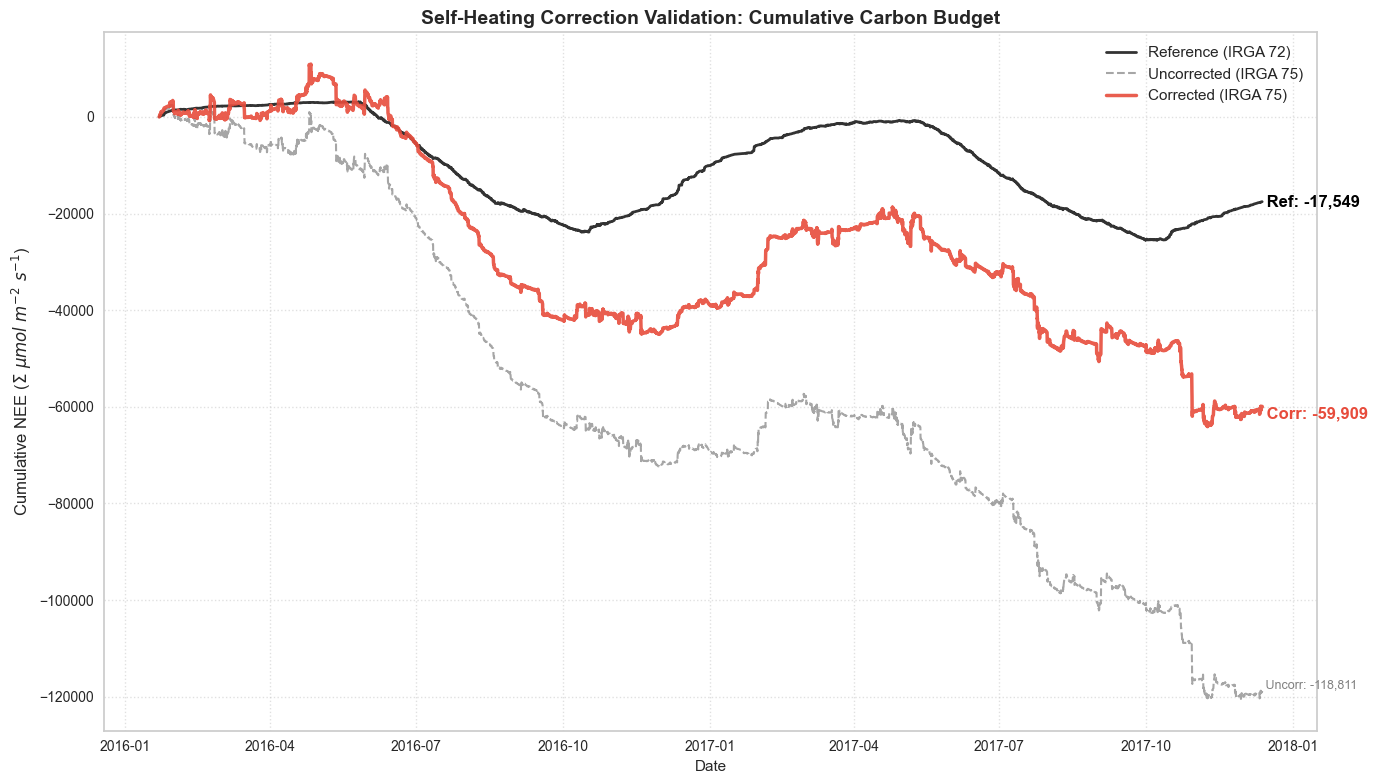

Total Bias (Uncorrected): -101,263 (-577.0%)
Total Bias (Corrected):   -42,360 (-241.4%)


In [14]:
import matplotlib.pyplot as plt
import pandas as pd


# Parallel measurements starting 27 May 2016
irga72_L1 = load_parquet(filepath=r"../../20_MERGE_DATA/22.4_FLUXES_L1_IRGA72+METEO7_2016-2024.parquet")
irga75_L1 = load_parquet(filepath=r"../../20_MERGE_DATA/21.4_FLUXES_L1_noSHC_IRGA75+METEO7.parquet")
irga72_L1 = irga72_L1['FC'].copy()
irga75_L1 = irga75_L1['FC'].copy()
irga75_L11 = res['NEE_OP_CORR'].copy()


# --- 1. PREPARE DATA ---
# Align all series to the same index and drop NaNs to ensure a fair cumulative comparison
# (If one sensor is down, we shouldn't sum the others for that timestamp)
df_plot = pd.DataFrame({
    'Reference (CP-72)': irga72_L1,
    'Uncorrected (OP-75)': irga75_L1,
    'Corrected (OP-75)': irga75_L11
}).dropna()

# Calculate Cumulative Sum
df_cumsum = df_plot.cumsum()

# --- 2. PLOT ---
plt.figure(figsize=(14, 8))

# A. Plot Reference (Solid Black)
plt.plot(df_cumsum.index, df_cumsum['Reference (CP-72)'], 
         label='Reference (IRGA 72)', color='black', lw=2, alpha=0.8, zorder=2)

# B. Plot Uncorrected (Dashed Gray) - Shows the original bias
plt.plot(df_cumsum.index, df_cumsum['Uncorrected (OP-75)'], 
         label='Uncorrected (IRGA 75)', color='gray', lw=1.5, ls='--', alpha=0.7, zorder=1)

# C. Plot Corrected (Solid Red) - Should track the Reference
plt.plot(df_cumsum.index, df_cumsum['Corrected (OP-75)'], 
         label='Corrected (IRGA 75)', color='#e74c3c', lw=2.5, alpha=0.9, zorder=3)

# --- 3. ANNOTATIONS & STYLE ---
# Get final values for text annotation
final_ref = df_cumsum['Reference (CP-72)'].iloc[-1]
final_unc = df_cumsum['Uncorrected (OP-75)'].iloc[-1]
final_cor = df_cumsum['Corrected (OP-75)'].iloc[-1]

# Add text labels at the end of the lines
plt.text(df_cumsum.index[-1], final_ref, f" Ref: {final_ref:,.0f}", 
         va='center', color='black', fontweight='bold')
plt.text(df_cumsum.index[-1], final_unc, f" Uncorr: {final_unc:,.0f}", 
         va='bottom', color='gray', fontsize=9)
plt.text(df_cumsum.index[-1], final_cor, f" Corr: {final_cor:,.0f}", 
         va='top', color='#e74c3c', fontweight='bold')

# Formatting
plt.title("Self-Heating Correction Validation: Cumulative Carbon Budget", fontsize=14, fontweight='bold')
plt.ylabel(r"Cumulative NEE ($\Sigma\ \mu mol\ m^{-2}\ s^{-1}$)", fontsize=12)
plt.xlabel("Date")
plt.legend(fontsize=11)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

# --- 4. PRINT METRICS ---
diff_raw = final_unc - final_ref
diff_corr = final_cor - final_ref

print(f"Total Bias (Uncorrected): {diff_raw:,.0f} ({(diff_raw/abs(final_ref))*100:+.1f}%)")
print(f"Total Bias (Corrected):   {diff_corr:,.0f} ({(diff_corr/abs(final_ref))*100:+.1f}%)")

In [15]:
res

,FCT_UNSC_gfRF,FC,USTAR,DAYTIME,GROUP_CLASSVAR,SF,FCT,NEE_OP_CORR
TIMESTAMP_MIDDLE,,,,,,,,
2004-03-30 14:45:00,25.252865,NaN,0.468909,1.0,9.0,0.198257,5.006557,NaN
2004-03-30 15:15:00,25.206804,NaN,NaN,1.0,NaN,0.140020,3.529449,NaN
2004-03-30 15:45:00,25.419718,NaN,0.565546,1.0,12.0,0.151051,3.839665,NaN
2004-03-30 16:15:00,23.671549,NaN,0.502164,1.0,10.0,0.188741,4.467793,NaN
2004-03-30 16:45:00,22.028738,NaN,0.345264,1.0,6.0,0.264050,5.816696,NaN
...,...,...,...,...,...,...,...,...
2019-12-31 21:45:00,9.843578,NaN,NaN,0.0,NaN,0.062468,0.614904,NaN
2019-12-31 22:15:00,10.139026,NaN,NaN,0.0,NaN,0.062468,0.633360,NaN
2019-12-31 22:45:00,10.190094,NaN,NaN,0.0,NaN,0.063731,0.649428,NaN


# Overwrite non-corrected `FC` with corrected version

In [16]:
df['FC'].describe()

count    219562.000000
mean         -3.388636
std          91.136919
min       -5050.860000
25%          -8.323713
50%          -0.750189
75%           2.596885
max        3725.790000
Name: FC, dtype: float64

In [17]:
df['FC'] = res['NEE_OP_CORR'].copy()
df['FC'].describe()

count    219562.000000
mean         -1.355543
std          91.134127
min       -5049.226415
25%          -5.766817
50%           0.395998
75%           4.401615
max        3726.171700
Name: FC, dtype: float64

# Save to file

In [18]:
filename = "42_FLUXES_L11_SHC_IRGA75+METEO7_2004-2017_2019"
# df.to_csv(f"{filename}.csv", index=True)
save_parquet(data=df, filename=filename)

Saved file 42_FLUXES_L11_SHC_IRGA75+METEO7_2004-2017_2019.parquet (3.482 seconds).


'42_FLUXES_L11_SHC_IRGA75+METEO7_2004-2017_2019.parquet'

# ✅END OF NOTEBOOK

In [19]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-12-04 16:31:55
